# Bloque A.1 — Prototipo de Extracción y Comparación de Embeddings Faciales

**Proyecto:** Sistema de Reconocimiento Facial para Control de Asistencia (Gimnasio)
**Fase:** CRISP-ML(Q) — Fase 3, Model Engineering (primer prototipo)

### Objetivo de este notebook
Confirmar, con el mínimo código posible, que el modelo pre-entrenado **Facenet512** (a través de la librería **DeepFace**) es capaz de:
1. Detectar un rostro dentro de una foto.
2. Convertirlo en un vector numérico de 512 posiciones (el *embedding*).
3. Reconocer correctamente cuándo dos fotos son de la **misma persona** y cuándo son de **personas distintas**, comparando esos vectores.

No construimos base de datos ni backend todavía — este es el experimento más pequeño y rápido posible para validar que el núcleo del sistema funciona antes de invertir tiempo en todo lo demás.

## Herramientas necesarias
* **Python 3.9 o superior** (el mismo que usaste en Machine Learning I sirve).
* **Jupyter Notebook / JupyterLab** (o Visual Studio Code con la extensión de Jupyter) — la misma forma en la que corriste el notebook de CelebA.
* Conexión a internet la **primera vez** que ejecutes este notebook: DeepFace descarga automáticamente los pesos del modelo Facenet512 (~95 MB) desde GitHub la primera vez que se usa, y los guarda en tu computadora (carpeta `~/.deepface/weights`) para las siguientes veces, así que no se vuelve a descargar.

### Instalación (ejecuta esto una sola vez en tu computadora)
Corre la siguiente celda. Si tu sistema te muestra un error de tipo `externally-managed-environment`, vuelve a correrla agregando `--break-system-packages` al final de cada línea `pip install`. Si usas un entorno virtual (venv o conda), probablemente no necesitarás ese parámetro.

In [1]:
# Instalación de dependencias. Ejecuta esta celda UNA sola vez.
#
# IMPORTANTE: usamos %pip (con signo de porcentaje), NO !pip (con signo de exclamación).
# Anaconda permite tener varios "entornos" separados (como cajas de herramientas distintas),
# por ejemplo el tuyo se llama 'machine2026'. El comando !pip a veces instala en el entorno
# equivocado sin avisarte (parece exitoso, pero tu notebook sigue sin ver el paquete).
# %pip, en cambio, instala SIEMPRE en el mismo Python que está ejecutando este notebook.
%pip install deepface tf-keras h5py
# Si te aparece 'externally-managed-environment', usa en su lugar:
# %pip install deepface tf-keras h5py --break-system-packages

Note: you may need to restart the kernel to use updated packages.


**Después de que termine la instalación, reinicia el kernel** (menú *Kernel → Restart Kernel...* en Jupyter, o el ícono de reinicio en VS Code) **antes de continuar**. Esto es necesario porque Python ya había cargado ciertos módulos en memoria antes de instalar los paquetes nuevos, y no los "verá" hasta que el proceso se reinicie. Luego sigue ejecutando las celdas de abajo en orden, empezando por la de diagnóstico.

## Paso 0: Verificar que el entorno está correctamente configurado

Antes de tocar fotos ni modelos, confirmamos que las librerías quedaron instaladas **en el mismo Python que está corriendo este notebook**. Si algo aparece como `[PROBLEMA]` abajo, hay que resolverlo antes de seguir — todo lo demás fallará igual.

In [1]:
import sys
print('Python que está usando este notebook (kernel):')
print(sys.executable)
print()

def verificar(nombre_paquete, import_func):
    try:
        version = import_func()
        print(f"[OK] {nombre_paquete} disponible (versión {version})")
        return True
    except ImportError as e:
        print(f"[PROBLEMA] {nombre_paquete} NO está disponible en este kernel: {e}")
        print(f"          Solución: ejecuta en una celda nueva -> %pip install {nombre_paquete.lower()}")
        print(f"          y luego reinicia el kernel.")
        return False

ok_h5py = verificar('h5py', lambda: __import__('h5py').__version__)
ok_tf = verificar('tensorflow', lambda: __import__('tensorflow').__version__)
ok_deepface = verificar('deepface', lambda: __import__('deepface').__version__ if hasattr(__import__('deepface'), '__version__') else 'instalado')

if ok_h5py and ok_tf and ok_deepface:
    print('\nTodo listo. Puedes continuar con el Paso 1.')
else:
    print('\nResuelve los [PROBLEMA] de arriba, reinicia el kernel, y vuelve a correr esta celda antes de seguir.')

Python que está usando este notebook (kernel):
D:\anaconda3\envs\machine2026\python.exe

[OK] h5py disponible (versión 3.14.0)
[OK] tensorflow disponible (versión 2.21.0)
[OK] deepface disponible (versión 0.0.101)

Todo listo. Puedes continuar con el Paso 1.


## Paso 1: Prepara tus fotos de prueba

1. En la misma carpeta donde guardaste este notebook, crea una subcarpeta llamada exactamente `fotos_prueba`.
2. Coloca ahí tus 3 fotos. Te recomiendo nombrarlas así, para que los resultados que imprimamos más abajo se lean con claridad:
   * `yo_1.jpg`, `yo_2.jpg` → dos fotos tuyas, en momentos o ángulos distintos.
   * `otra_persona.jpg` → (opcional pero muy recomendable) una foto de otra persona cualquiera (un familiar, un amigo, o incluso una foto descargada de internet). Esto nos permite comprobar no solo que el sistema te reconoce a ti, sino que **rechaza correctamente a alguien que no eres tú** — igual de importante que el primer caso.

Formatos aceptados: `.jpg`, `.jpeg`, `.png`. Que el rostro se vea de frente y con luz razonable; no hace falta que sea una foto profesional.

Fotos encontradas (3): ['otra_persona.jpeg', 'yo_1.jpeg', 'yo_2.jpeg']


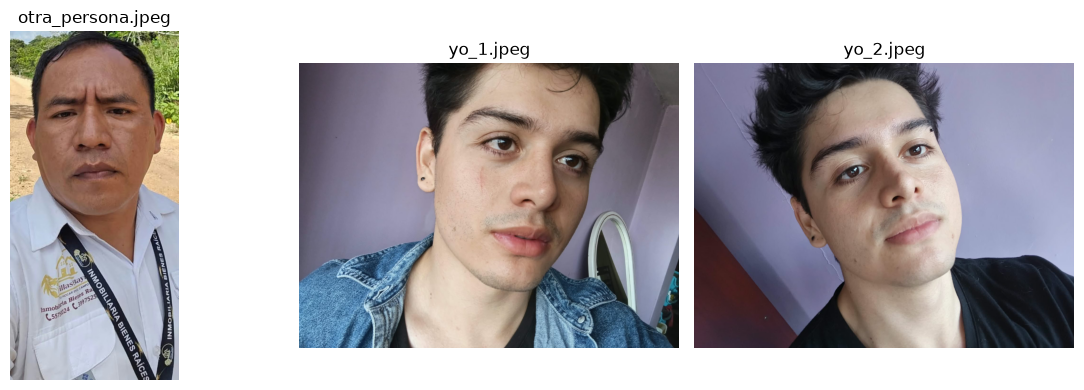

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CARPETA_FOTOS = "fotos_prueba"

assert os.path.isdir(CARPETA_FOTOS), (
    f"No encontré la carpeta '{CARPETA_FOTOS}'. Créala junto a este notebook y coloca "
    "tus fotos ahí antes de continuar."
)

extensiones_validas = ('.jpg', '.jpeg', '.png')
fotos = sorted(f for f in os.listdir(CARPETA_FOTOS) if f.lower().endswith(extensiones_validas))

assert len(fotos) >= 2, "Necesitas al menos 2 fotos en la carpeta 'fotos_prueba' para poder comparar."

print(f"Fotos encontradas ({len(fotos)}): {fotos}")

# Visualizamos todas las fotos encontradas antes de procesarlas, para confirmar
# visualmente que son las correctas y que el rostro se ve con claridad.
fig, axes = plt.subplots(1, len(fotos), figsize=(4 * len(fotos), 4))
if len(fotos) == 1:
    axes = [axes]
for ax, nombre in zip(axes, fotos):
    img = mpimg.imread(os.path.join(CARPETA_FOTOS, nombre))
    ax.imshow(img)
    ax.set_title(nombre)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Paso 2: ¿Qué hace `DeepFace.verify()`?

**Concepto técnico:** `DeepFace.verify()` recibe dos rutas de imagen y hace tres cosas internamente:
1. **Detecta** el rostro dentro de cada imagen (recorta la cara, ignorando el fondo).
2. **Extrae el embedding** de cada rostro con el modelo elegido (en nuestro caso, Facenet512 → un vector de 512 números por rostro).
3. **Calcula la distancia** entre esos dos vectores (por defecto, distancia coseno) y la compara contra un **umbral (threshold)** ya calibrado por los creadores del modelo: si la distancia es **menor** al umbral, concluye que son la misma persona; si es **mayor**, concluye que son personas distintas.

El resultado es un diccionario de Python con, entre otras, estas claves:
* `verified` → `True` o `False` (la decisión final).
* `distance` → qué tan lejos están los dos vectores (cuanto más bajo, más parecidos).
* `threshold` → el umbral de referencia usado para decidir.

A continuación comparamos **todas las combinaciones posibles** entre las fotos que pusiste en la carpeta.

In [3]:
from deepface import DeepFace
import os

MODELO = "Facenet512"

foto1 = fotos[0]
foto2 = fotos[1]

ruta1 = os.path.abspath(os.path.join(CARPETA_FOTOS, foto1))
ruta2 = os.path.abspath(os.path.join(CARPETA_FOTOS, foto2))

print("Imagen 1:", ruta1)
print("Existe:", os.path.isfile(ruta1))
print()

print("Imagen 2:", ruta2)
print("Existe:", os.path.isfile(ruta2))
print()

try:
    resultado = DeepFace.verify(
        img1_path=ruta1,
        img2_path=ruta2,
        model_name=MODELO
    )

    print(resultado)

except Exception as e:
    import traceback

    print("\n===== ERROR COMPLETO =====")
    traceback.print_exc()

26-10-02 11:08:35 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.


Imagen 1: C:\Users\Arman\Desktop\Machine-Learning-II\Proyecto Final\fotos_prueba\otra_persona.jpeg
Existe: True

Imagen 2: C:\Users\Arman\Desktop\Machine-Learning-II\Proyecto Final\fotos_prueba\yo_1.jpeg
Existe: True


===== ERROR COMPLETO =====


Traceback (most recent call last):
  File "D:\anaconda3\envs\machine2026\Lib\site-packages\deepface\modules\verification.py", line 189, in extract_embeddings_and_facial_areas
    img_embeddings, img_facial_areas = __extract_faces_and_embeddings(
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\envs\machine2026\Lib\site-packages\deepface\modules\verification.py", line 269, in __extract_faces_and_embeddings
    detection.extract_faces(
  File "D:\anaconda3\envs\machine2026\Lib\site-packages\deepface\modules\detection.py", line 150, in extract_faces
    face_objs = detect_faces(
                ^^^^^^^^^^^^^
  File "D:\anaconda3\envs\machine2026\Lib\site-packages\deepface\modules\detection.py", line 296, in detect_faces
    face_detector: Detector = modeling.build_model(
                              ^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\envs\machine2026\Lib\site-packages\deepface\modules\modeling.py", line 184, in build_model
    cached_mod

In [3]:
import cv2

print("Versión de OpenCV:", cv2.__version__)
print("Ruta de cv2:", cv2.__file__)
print("Ruta de datos de OpenCV:", cv2.data.haarcascades)

Versión de OpenCV: 5.0.0
Ruta de cv2: D:\anaconda3\envs\machine2026\Lib\site-packages\cv2\__init__.py
Ruta de datos de OpenCV: D:\anaconda3\envs\machine2026\Lib\site-packages\cv2\data\


In [4]:
import os
import cv2

ruta_haar = os.path.join(
    cv2.data.haarcascades,
    "haarcascade_frontalface_default.xml"
)

print("Archivo esperado:")
print(ruta_haar)

print("\n¿Existe?")
print(os.path.isfile(ruta_haar))

Archivo esperado:
D:\anaconda3\envs\machine2026\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml

¿Existe?
False


### Visualizando cada comparación
Para que sea más fácil interpretar los resultados, mostramos cada par de fotos comparadas una al lado de la otra, junto con el veredicto obtenido.

In [ ]:
for foto1, foto2, veredicto, distancia, umbral in resultados:
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, nombre in zip(axes, (foto1, foto2)):
        img = mpimg.imread(os.path.join(CARPETA_FOTOS, nombre))
        ax.imshow(img)
        ax.set_title(nombre, fontsize=9)
        ax.axis('off')
    subtitulo = veredicto if distancia is None else f"{veredicto}  (distancia={distancia:.3f})"
    fig.suptitle(subtitulo, fontsize=11)
    plt.tight_layout()
    plt.show()

## Paso 3: viendo el embedding con tus propios ojos

Ahora extraemos el embedding de una sola foto con `DeepFace.represent()`, para confirmar de forma concreta lo que hemos discutido: cada rostro se convierte en un **vector de 512 números** (con Facenet512). Estos números por sí solos no significan nada interpretable para un humano — no hay una posición que represente "tamaño de la nariz", por ejemplo — pero la red aprendió a organizarlos de forma que rostros parecidos producen vectores matemáticamente cercanos.

In [ ]:
embedding_resultado = DeepFace.represent(img_path=os.path.join(CARPETA_FOTOS, fotos[0]),
                                          model_name=MODELO)
vector = embedding_resultado[0]["embedding"]

print(f"Foto analizada: {fotos[0]}")
print(f"Longitud del vector (embedding): {len(vector)}")
print(f"Primeros 10 valores: {[round(v, 4) for v in vector[:10]]}")

## ¿Cómo interpretar los resultados?

* Si tus dos fotos (`yo_1.jpg` y `yo_2.jpg`) dieron **MISMA PERSONA**, y la comparación contra `otra_persona.jpg` dio **PERSONAS DISTINTAS**, el prototipo quedó validado: el modelo funciona correctamente para nuestro caso de uso.
* Si algo salió al revés (por ejemplo, no te reconoció a ti mismo entre dos fotos tuyas), antes de preocuparte revisa: ¿las fotos tienen buena luz?, ¿el rostro está de frente y sin cubrir ojos/cejas?, ¿la foto no está borrosa? Estos factores afectan mucho más al resultado que el modelo en sí (lo vimos también en la comparación con la literatura académica: el detector y la calidad de la imagen importan más que el modelo elegido).
* La longitud de 512 confirma que Facenet512 sí está siendo el modelo usado.

### Siguiente paso: Bloque A.2
Con esto validado, el siguiente paso es construir la función de **enrollment** (matricular a una persona guardando su embedding) y la función de **reconocimiento** (comparar un embedding nuevo contra todos los guardados), todavía sin base de datos real — solo un archivo local — como puente hacia el Bloque C, donde ya lo conectamos a PostgreSQL.